In [1]:
# INTRODUCTION

# This notebook implements an image classification model using CNN.
# The model is trained on a flower dataset with multiple classes.
# Deep learning is used to extract features from images.
# The system predicts the class of unseen flower images.

In [2]:
# IMPORTING LIBRARIES

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
# USING DATASET "five_type_flowers"

# Dataset path
data_dir = "dataset/five_type_flowers"

# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 2500 files belonging to 5 classes.
Using 2000 files for training.
Found 2500 files belonging to 5 classes.
Using 500 files for validation.


In [4]:
# Checking Class Names in selected dataset
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [5]:
# Normalizing (DATA) images

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [6]:
# Data augmentation to improve generalization

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

In [7]:
# Building CNN(CONVOLUTIONAL NEURAL NETWORK) Model

# Better CNN model
model = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128,128,3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])


C:\Users\Sanket M\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Compiling CNN Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# TRAINING MODEL

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - accuracy: 0.2040 - loss: 1.6103 - val_accuracy: 0.2220 - val_loss: 1.6091
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.2435 - loss: 1.6069 - val_accuracy: 0.2760 - val_loss: 1.5960
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.2710 - loss: 1.5662 - val_accuracy: 0.3300 - val_loss: 1.5128
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.3305 - loss: 1.5101 - val_accuracy: 0.3620 - val_loss: 1.4663
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.3380 - loss: 1.4880 - val_accuracy: 0.3700 - val_loss: 1.4530
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.3510 - loss: 1.4738 - val_accuracy: 0.3680 - val_loss: 1.4383
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.3500 - loss: 1.4619 - val_accuracy: 0.3860 - val_loss: 1.4275
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.3640 - loss: 1.4531 - val_accu

In [10]:
# Evaluating Model
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3840 - loss: 1.4150
Validation Accuracy: 0.3840000033378601


In [11]:
# High Accuracy Model (MobileNetV2)

# Import pretrained model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

# Freezing base model
base_model.trainable = False

# Building final model
model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

In [12]:
# Compiling Model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# Using EarlyStopping and ReduceLROnPlateau Callbacks for better Accuracy

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [14]:
# Training Model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 190ms/step - accuracy: 0.4605 - loss: 1.5372 - val_accuracy: 0.7500 - val_loss: 0.7463 - learning_rate: 3.0000e-04
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.6840 - loss: 0.9280 - val_accuracy: 0.8140 - val_loss: 0.5897 - learning_rate: 3.0000e-04
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.7395 - loss: 0.7916 - val_accuracy: 0.8260 - val_loss: 0.5397 - learning_rate: 3.0000e-04
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.7575 - loss: 0.6808 - val_accuracy: 0.8320 - val_loss: 0.5183 - learning_rate: 3.0000e-04
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.7800 - loss: 0.6362 - val_accuracy: 0.8200 - val_loss: 0.5133 - learning_rate: 3.0000e-04
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.7695 - loss: 0.6231 - val_accuracy: 0.8280 - val_loss: 0.4994 - learning_rate: 3.0000e-04
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 180ms/step - accu

In [32]:
# Evaluating Model
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.8480 - loss: 0.4740
Validation Accuracy: 0.8479999899864197


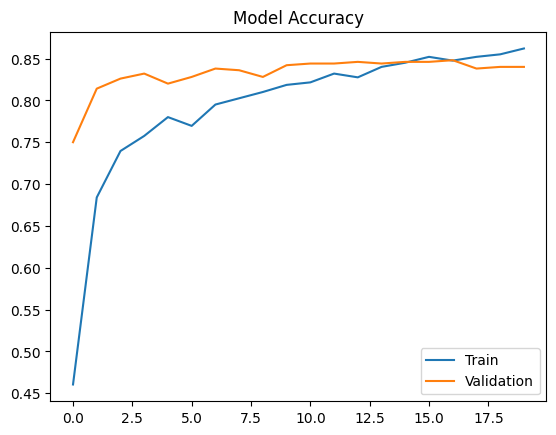

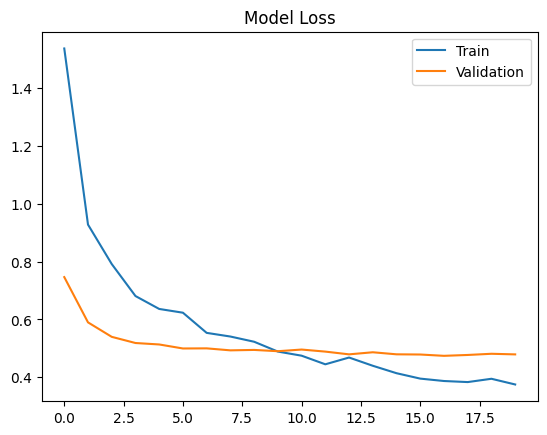

In [25]:
# Plotting Accuracy & Loss

# Accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# # Loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


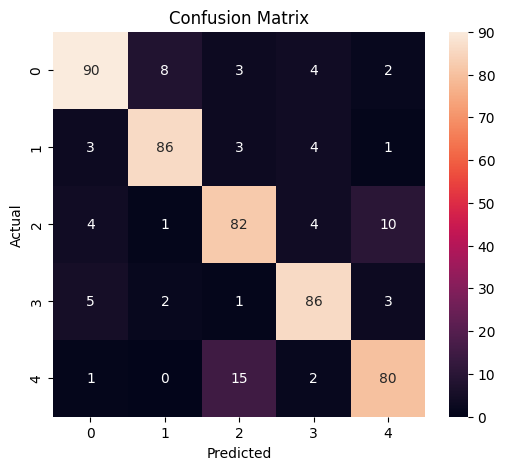

In [17]:
# Plotting Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       daisy       0.87      0.84      0.86       107
   dandelion       0.89      0.89      0.89        97
        rose       0.79      0.81      0.80       101
   sunflower       0.86      0.89      0.87        97
       tulip       0.83      0.82      0.82        98

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500



In [19]:
# Saving Model
model.save("flower_cnn_model.h5")

In [20]:
# Loading Model
from tensorflow.keras.models import load_model

loaded_model = load_model("flower_cnn_model.h5")

In [26]:
# Prediction on New Image

# Load image
img_path = r"dataset\five_type_flowers\sunflower\35477171_13cb52115c_n.jpg"

img = load_img(img_path, target_size=(128,128))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Predicted Class: sunflower


In [31]:
# Testing Prediction on Loaded Model

pred = loaded_model.predict(img_array)
print("Loaded Model Prediction:", class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Loaded Model Prediction: sunflower


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step


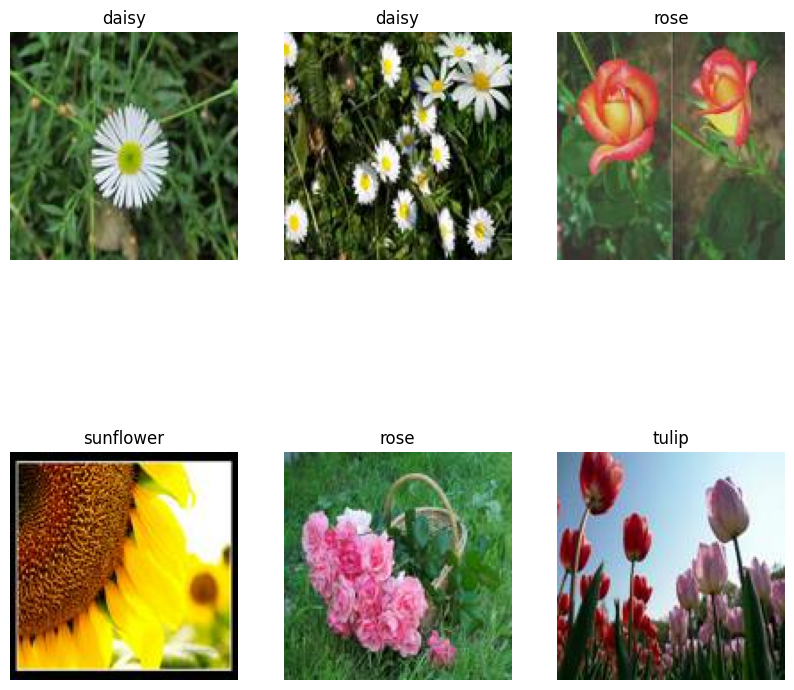

In [33]:
# Visual predictions
for images, labels in val_ds.take(1):
    preds = model.predict(images)

    plt.figure(figsize=(10,10))
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[np.argmax(preds[i])])
        plt.axis("off")
    plt.show()

In [28]:
# Full prediction pipeline
def predict_image(img_path):
    img = load_img(img_path, target_size=(128,128))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    return class_names[np.argmax(pred)]

print(predict_image(r"dataset\five_type_flowers\daisy\21652746_cc379e0eea_m.jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
daisy


In [29]:
# Batch Predictions

# Predict multiple images
test_images = [r"dataset\five_type_flowers\rose\172311368_49412f881b.jpg", 
               r"dataset\five_type_flowers\tulip\112334842_3ecf7585dd.jpg"]

for img in test_images:
    print(img, "→", predict_image(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
dataset\five_type_flowers\rose\172311368_49412f881b.jpg → rose
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
dataset\five_type_flowers\tulip\112334842_3ecf7585dd.jpg → tulip


In [ ]:
# CONCLUSION

# The CNN model successfully classifies flower images into categories.
# The model extracts features using convolutional layers.
# Data augmentation and dropout improved generalization and accuracy.
# Performance is evaluated using accuracy and loss metrics.
# Evaluation metrics such as confusion matrix and classification report validate performance.
# The model can be deployed for real-time image classification applications and image recognition systems.